In [1]:
import os, sys, pickle, warnings, datetime, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

import tensorflow as tf
# tf.compat.v1.disable_v2_behavior()  # uncomment if you're running TF2

sys.path.append("../../src")

from example_lorenz_mine_layered import generate_lorenz_data
from autoencoder_lorenz import full_network
from training_lorenz import create_feed_dictionary

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

warnings.filterwarnings("ignore")

/home/szupernikusz/miniconda3/envs/mars/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/home/szupernikusz/miniconda3/envs/mars/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/home/szupernikusz/miniconda3/envs/mars/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/home/szupernikusz/miniconda3/e

### User Settings

In [2]:
# ------------------------------------------------------------
# User settings
# ------------------------------------------------------------
DATA_SEED = 0
OBS_DIM = 50
LATENT_DIM = 3
POLY_ORDER = 3            # only needed if you also simulate SINDy; not used here
noise_strength = 1e-3

mlp_depths = [3, 4]#[1,2,3,4]
train_seeds_per_depth = [140, 141, 142, 143]  # 4 models per depth

# where the models live (adjust if needed)
data_path = os.path.join(os.getcwd())
# output embeddings
emb_out_path = "lorenz_latent_embeddings_nonlin_no-nest_depth-3-4.pkl"

### Building Model Name List

In [3]:
# ============================================================
# 1) Build model name list (4 depths × 2 seeds)
# ============================================================
def model_name(depth, seed):
    return f"lorenz_dcl_mixer_depth-{depth}_trainseed-{seed}"

model_names = []
for d in mlp_depths:
    for s in train_seeds_per_depth:
        model_names.append(model_name(d, s))

print("Models to load:")
for n in model_names:
    print("  ", n)


Models to load:
   lorenz_dcl_mixer_depth-3_trainseed-140
   lorenz_dcl_mixer_depth-3_trainseed-141
   lorenz_dcl_mixer_depth-3_trainseed-142
   lorenz_dcl_mixer_depth-3_trainseed-143
   lorenz_dcl_mixer_depth-4_trainseed-140
   lorenz_dcl_mixer_depth-4_trainseed-141
   lorenz_dcl_mixer_depth-4_trainseed-142
   lorenz_dcl_mixer_depth-4_trainseed-143


In [4]:
model_names = [
    "lorenz_seed_140_2026_01_29_02_06_27_332258",
    "lorenz_seed_141_2026_01_29_06_31_25_943740",
    "lorenz_seed_142_2026_01_31_00_52_32_426128",
    "lorenz_seed_143_2026_01_31_05_02_45_716181",
    "lorenz_seed_140_3_2026_01_31_10_15_54_121536",
    "lorenz_seed_141_3_2026_02_01_01_30_09_829774",
    "lorenz_seed_142_3_2026_02_01_05_45_02_807147",
    "lorenz_seed_143_3_2026_02_01_10_09_16_584588"
]


In [5]:
# ============================================================
# 2) Load models into isolated TF graphs
# ============================================================
def load_model_into_graph(save_name, base_dir):
    """
    Loads params, builds the AE-SINDy graph, returns an experiment dict.
    """
    graph = tf.Graph()
    with graph.as_default():
        params = pickle.load(open(os.path.join(base_dir, save_name + "_params.pkl"), "rb"))
        params["save_name"] = os.path.join(base_dir, save_name)

        network = full_network(params)

        learning_rate = tf.placeholder(tf.float32, name="learning_rate")

        # collect outputs in a consistent order
        run_tuple = tuple(network[k] for k in network.keys())

        saver = tf.train.Saver(var_list=tf.get_collection(tf.GraphKeys.GLOBAL_VARIABLES))

    return {
        "graph": graph,
        "params": params,
        "network": network,
        "run_tuple": run_tuple,
        "saver": saver,
        "learning_rate": learning_rate,
    }

experiments = {}
for name in model_names:
    experiments[name] = load_model_into_graph(name, data_path)

print("Loaded experiments:", len(experiments))



The TensorFlow contrib module will not be included in TensorFlow 2.0.
For more information, please see:
  * https://github.com/tensorflow/community/blob/master/rfcs/20180907-contrib-sunset.md
  * https://github.com/tensorflow/addons
  * https://github.com/tensorflow/io (for I/O related ops)
If you depend on functionality not listed there, please file an issue.




Loaded experiments: 8


### Testing

#### Test trajectory -- specific for mlp_depth

In [6]:
# ============================================================
# 3) Test trajectory definition (same z0,t for all depths)
#    But we generate x(t) separately per depth to match the trained sensor.
# ============================================================
t = np.arange(0, 20, 0.01)
z0 = np.array([[-8, 7, 27]], dtype=np.float32)

def make_test_data_for_depth(depth):
    """
    Generate test data with the SAME nested mixer family used in training.
    IMPORTANT: depth controls the observation map.
    """
    data = generate_lorenz_data(
        z0, t,
        n_points=OBS_DIM,
        linear=False,
        normalization=np.array([1/40, 1/40, 1/40], dtype=np.float32),
        seed=DATA_SEED,
        n_layers=int(depth),
        nested=True,
        max_layers=4,
        noise_strength=noise_strength,
        smooth=True,
        sg_window=11,
        sg_poly=3,
    )

    # flatten for AE-SINDy feed_dict (matches training code expectations)
    data["x"]  = data["x"].reshape((-1, OBS_DIM))
    data["dx"] = data["dx"].reshape((-1, OBS_DIM))
    data["z"]  = data["z"].reshape((-1, LATENT_DIM))
    data["dz"] = data["dz"].reshape((-1, LATENT_DIM))
    return data


#### Inference to get latent embeddings

In [7]:
# ============================================================
# 4) Inference helper: run model on test data -> latent embedding Z_hat
# ============================================================
def run_inference(exp, test_data):
    graph = exp["graph"]
    params = exp["params"]
    saver = exp["saver"]
    run_tpl = exp["run_tuple"]
    network = exp["network"]

    with tf.Session(graph=graph) as sess:
        sess.run(tf.global_variables_initializer())
        saver.restore(sess, params["save_name"])

        feed = create_feed_dictionary(test_data, params)
        out = sess.run(run_tpl, feed_dict=feed)

    results = {k: out[i] for i, k in enumerate(network.keys())}
    # AE latent embedding is typically under key 'z'
    Z_hat = results["z"]
    return Z_hat, results


In [ ]:
#print(single_traj_results['model1']['test_set_results']['z'][0], test_data['z'][0])

## Alignments

In [8]:
# ============================================================
# 5) Alignment + PCA utilities
# ============================================================
def affine_align_and_r2(Z_src, Z_tgt):
    lm = LinearRegression(fit_intercept=True)
    lm.fit(Z_src, Z_tgt)
    Z_aligned = lm.predict(Z_src)
    r2 = r2_score(Z_tgt, Z_aligned, multioutput="uniform_average")
    return Z_aligned, float(r2)

def pca_3d_from_X(X):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    pca = PCA(n_components=3, random_state=0)
    Zp = pca.fit_transform(Xs)
    return Zp


### Looping through models

In [10]:
# ============================================================
# 6) Main evaluation loop:
#    For each depth:
#      - generate test data (depth-specific x)
#      - run both models
#      - compute affine R² to GT latent
#      - keep the best one
#      - also compute PCA baseline
#    Save everything to a pickle at the end.
# ============================================================
emb_store = {
    "meta": {
        "t": t,
        "z0": z0,
        "DATA_SEED": DATA_SEED,
        "OBS_DIM": OBS_DIM,
        "LATENT_DIM": LATENT_DIM,
        "noise_strength": noise_strength,
        "nested": True,
        "max_layers": 4,
        "train_seeds_per_depth": train_seeds_per_depth,
    },
    "per_depth": {}
}

text = ""

for d in mlp_depths:
    print("\n" + "="*80)
    print(f"DEPTH {d}: generating test data + running two models")
    text += "\n" + "="*80 + "\n"
    text += f"DEPTH {d}: generating test data + running two models\n"

    test_data = make_test_data_for_depth(d)
    Z_gt = test_data["z"]          # (N,3)
    X = test_data["x"]             # (N,OBS_DIM)

    # PCA baseline (raw) + aligned score
    Z_pca = pca_3d_from_X(X)
    Z_pca_aln, r2_pca = affine_align_and_r2(Z_pca, Z_gt)
    print(f"\n\n  PCA: R²={r2_pca:.4f}\n\n")
    text += f"\n\n  PCA: R²={r2_pca:.4f}\n\n"
    
    # run both models for this depth
    candidates = []
    for i, s in enumerate(train_seeds_per_depth):
        name = model_names[i]
        Z_hat, _ = run_inference(experiments[name], test_data)
        Z_hat_aln, r2_hat = affine_align_and_r2(Z_hat, Z_gt)
        candidates.append({
            "name": name,
            "train_seed": s,
            "Z_raw": Z_hat,
            "Z_aligned": Z_hat_aln,
            "r2": r2_hat,
        })
        print(f"\n\n  {name}: R²={r2_hat:.4f}")
        text += f"\n\n  {name}: R²={r2_hat:.4f}"

    # choose best
    best = max(candidates, key=lambda c: c["r2"])
    print(f"\--> BEST depth {d}: {best['name']} (R²={best['r2']:.4f})\n\n")

    emb_store["per_depth"][int(d)] = {
        "test_data": {   # keep only what we need (avoid huge dicts if desired)
            "X": X,
            "Z_gt": Z_gt,
        },
        "pca": {
            "Z_raw": Z_pca,
            "Z_aligned": Z_pca_aln,
            "r2": r2_pca,
        },
        "candidates": candidates,
        "best": best,
    }

# save
with open(emb_out_path, "wb") as f:
    pickle.dump(emb_store, f, protocol=pickle.HIGHEST_PROTOCOL)

print("\nSaved embeddings to:", emb_out_path)



DEPTH 3: generating test data + running two models


  PCA: R²=0.9405


INFO:tensorflow:Restoring parameters from /home/szupernikusz/Projects/BayesianSindyAutoencoder/exmaples/lorenz/lorenz_seed_140_2026_01_29_02_06_27_332258


  lorenz_seed_140_2026_01_29_02_06_27_332258: R²=0.6318
INFO:tensorflow:Restoring parameters from /home/szupernikusz/Projects/BayesianSindyAutoencoder/exmaples/lorenz/lorenz_seed_141_2026_01_29_06_31_25_943740


2026-02-01 17:08:29.662154: E tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:991] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-02-01 17:08:29.662216: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1640] Found device 0 with properties: 
name: NVIDIA GeForce RTX 5060 Laptop GPU major: 12 minor: 0 memoryClockRate(GHz): 1.56
pciBusID: 0000:02:00.0
2026-02-01 17:08:29.662273: I tensorflow/stream_executor/platform/default/dso_loader.cc:42] Successfully opened dynamic library libcudart.so.10.1
2026-02-01 17:08:29.662293: I tensorflow/stream_executor/platform/default/dso_loader.cc:42] Successfully opened dynamic library libcublas.so.10
2026-02-01 17:08:29.662309: I tensorflow/stream_executor/platform/default/dso_loader.cc:42] Successfully opened dynamic library libcufft.so.10
2026-02-01 17:08:29.662324: I tensorflow/stream_executor/platform/default/dso_loader.cc:42] Successfully opened dy



  lorenz_seed_141_2026_01_29_06_31_25_943740: R²=0.7031
INFO:tensorflow:Restoring parameters from /home/szupernikusz/Projects/BayesianSindyAutoencoder/exmaples/lorenz/lorenz_seed_142_2026_01_31_00_52_32_426128


  lorenz_seed_142_2026_01_31_00_52_32_426128: R²=0.7001
INFO:tensorflow:Restoring parameters from /home/szupernikusz/Projects/BayesianSindyAutoencoder/exmaples/lorenz/lorenz_seed_143_2026_01_31_05_02_45_716181


  lorenz_seed_143_2026_01_31_05_02_45_716181: R²=0.6259
\--> BEST depth 3: lorenz_seed_141_2026_01_29_06_31_25_943740 (R²=0.7031)



DEPTH 4: generating test data + running two models


2026-02-01 17:08:29.871341: E tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:991] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-02-01 17:08:29.871377: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1640] Found device 0 with properties: 
name: NVIDIA GeForce RTX 5060 Laptop GPU major: 12 minor: 0 memoryClockRate(GHz): 1.56
pciBusID: 0000:02:00.0
2026-02-01 17:08:29.871416: I tensorflow/stream_executor/platform/default/dso_loader.cc:42] Successfully opened dynamic library libcudart.so.10.1
2026-02-01 17:08:29.871428: I tensorflow/stream_executor/platform/default/dso_loader.cc:42] Successfully opened dynamic library libcublas.so.10
2026-02-01 17:08:29.871438: I tensorflow/stream_executor/platform/default/dso_loader.cc:42] Successfully opened dynamic library libcufft.so.10
2026-02-01 17:08:29.871447: I tensorflow/stream_executor/platform/default/dso_loader.cc:42] Successfully opened dy



  PCA: R²=0.7282


INFO:tensorflow:Restoring parameters from /home/szupernikusz/Projects/BayesianSindyAutoencoder/exmaples/lorenz/lorenz_seed_140_2026_01_29_02_06_27_332258


  lorenz_seed_140_2026_01_29_02_06_27_332258: R²=0.7918
INFO:tensorflow:Restoring parameters from /home/szupernikusz/Projects/BayesianSindyAutoencoder/exmaples/lorenz/lorenz_seed_141_2026_01_29_06_31_25_943740


  lorenz_seed_141_2026_01_29_06_31_25_943740: R²=0.6673


2026-02-01 17:08:30.111811: E tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:991] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-02-01 17:08:30.111863: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1640] Found device 0 with properties: 
name: NVIDIA GeForce RTX 5060 Laptop GPU major: 12 minor: 0 memoryClockRate(GHz): 1.56
pciBusID: 0000:02:00.0
2026-02-01 17:08:30.111950: I tensorflow/stream_executor/platform/default/dso_loader.cc:42] Successfully opened dynamic library libcudart.so.10.1
2026-02-01 17:08:30.111980: I tensorflow/stream_executor/platform/default/dso_loader.cc:42] Successfully opened dynamic library libcublas.so.10
2026-02-01 17:08:30.111987: I tensorflow/stream_executor/platform/default/dso_loader.cc:42] Successfully opened dynamic library libcufft.so.10
2026-02-01 17:08:30.111992: I tensorflow/stream_executor/platform/default/dso_loader.cc:42] Successfully opened dy

INFO:tensorflow:Restoring parameters from /home/szupernikusz/Projects/BayesianSindyAutoencoder/exmaples/lorenz/lorenz_seed_142_2026_01_31_00_52_32_426128


  lorenz_seed_142_2026_01_31_00_52_32_426128: R²=0.7841
INFO:tensorflow:Restoring parameters from /home/szupernikusz/Projects/BayesianSindyAutoencoder/exmaples/lorenz/lorenz_seed_143_2026_01_31_05_02_45_716181


  lorenz_seed_143_2026_01_31_05_02_45_716181: R²=0.7421
\--> BEST depth 4: lorenz_seed_140_2026_01_29_02_06_27_332258 (R²=0.7918)



Saved embeddings to: lorenz_latent_embeddings_nonlin_no-nest_depth-3-4.pkl


2026-02-01 17:08:30.376713: E tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:991] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-02-01 17:08:30.376745: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1640] Found device 0 with properties: 
name: NVIDIA GeForce RTX 5060 Laptop GPU major: 12 minor: 0 memoryClockRate(GHz): 1.56
pciBusID: 0000:02:00.0
2026-02-01 17:08:30.376782: I tensorflow/stream_executor/platform/default/dso_loader.cc:42] Successfully opened dynamic library libcudart.so.10.1
2026-02-01 17:08:30.376790: I tensorflow/stream_executor/platform/default/dso_loader.cc:42] Successfully opened dynamic library libcublas.so.10
2026-02-01 17:08:30.376797: I tensorflow/stream_executor/platform/default/dso_loader.cc:42] Successfully opened dynamic library libcufft.so.10
2026-02-01 17:08:30.376803: I tensorflow/stream_executor/platform/default/dso_loader.cc:42] Successfully opened dy

In [11]:
print(text)


DEPTH 3: generating test data + running two models


  PCA: R²=0.9405



  lorenz_seed_140_2026_01_29_02_06_27_332258: R²=0.6318

  lorenz_seed_141_2026_01_29_06_31_25_943740: R²=0.7031

  lorenz_seed_142_2026_01_31_00_52_32_426128: R²=0.7001

  lorenz_seed_143_2026_01_31_05_02_45_716181: R²=0.6259
DEPTH 4: generating test data + running two models


  PCA: R²=0.7282



  lorenz_seed_140_2026_01_29_02_06_27_332258: R²=0.7918

  lorenz_seed_141_2026_01_29_06_31_25_943740: R²=0.6673

  lorenz_seed_142_2026_01_31_00_52_32_426128: R²=0.7841

  lorenz_seed_143_2026_01_31_05_02_45_716181: R²=0.7421


## 128-128 Models

In [27]:
# ------------------------------------------------------------
# User settings
# ------------------------------------------------------------
DATA_SEED = 0
OBS_DIM = 50
LATENT_DIM = 3
POLY_ORDER = 3            # only needed if you also simulate SINDy; not used here
noise_strength = 1e-3

mlp_depths = [1,2,3,4]
train_seeds_per_depth = [145, 146, 147, 148]  # 4 models per depth

# where the models live (adjust if needed)
data_path = os.path.join(os.getcwd(), "mine", "experiments", "models", "growing_mlp_128_sindy")

# output embeddings
emb_out_path = "lorenz_latent_embeddings_4x2_128.pkl"

In [28]:
# ============================================================
# 1) Build model name list (4 depths × 2 seeds)
# ============================================================
def model_name(depth, seed):
    return f"128-AE_lorenz_dcl_mixer_depth-{depth}_trainseed-{seed}"

model_names = []
for d in mlp_depths:
    for s in train_seeds_per_depth:
        model_names.append(model_name(d, s))

print("Models to load:")
for n in model_names:
    print("  ", n)


Models to load:
   128-AE_lorenz_dcl_mixer_depth-1_trainseed-145
   128-AE_lorenz_dcl_mixer_depth-1_trainseed-146
   128-AE_lorenz_dcl_mixer_depth-1_trainseed-147
   128-AE_lorenz_dcl_mixer_depth-1_trainseed-148
   128-AE_lorenz_dcl_mixer_depth-2_trainseed-145
   128-AE_lorenz_dcl_mixer_depth-2_trainseed-146
   128-AE_lorenz_dcl_mixer_depth-2_trainseed-147
   128-AE_lorenz_dcl_mixer_depth-2_trainseed-148
   128-AE_lorenz_dcl_mixer_depth-3_trainseed-145
   128-AE_lorenz_dcl_mixer_depth-3_trainseed-146
   128-AE_lorenz_dcl_mixer_depth-3_trainseed-147
   128-AE_lorenz_dcl_mixer_depth-3_trainseed-148
   128-AE_lorenz_dcl_mixer_depth-4_trainseed-145
   128-AE_lorenz_dcl_mixer_depth-4_trainseed-146
   128-AE_lorenz_dcl_mixer_depth-4_trainseed-147
   128-AE_lorenz_dcl_mixer_depth-4_trainseed-148


In [29]:
# ============================================================
# 2) Load models into isolated TF graphs
# ============================================================
def load_model_into_graph(save_name, base_dir):
    """
    Loads params, builds the AE-SINDy graph, returns an experiment dict.
    """
    graph = tf.Graph()
    with graph.as_default():
        params = pickle.load(open(os.path.join(base_dir, save_name + "_params.pkl"), "rb"))
        params["save_name"] = os.path.join(base_dir, save_name)

        network = full_network(params)

        learning_rate = tf.placeholder(tf.float32, name="learning_rate")

        # collect outputs in a consistent order
        run_tuple = tuple(network[k] for k in network.keys())

        saver = tf.train.Saver(var_list=tf.get_collection(tf.GraphKeys.GLOBAL_VARIABLES))

    return {
        "graph": graph,
        "params": params,
        "network": network,
        "run_tuple": run_tuple,
        "saver": saver,
        "learning_rate": learning_rate,
    }

experiments = {}
for name in model_names:
    experiments[name] = load_model_into_graph(name, data_path)

print("Loaded experiments:", len(experiments))


Loaded experiments: 16


In [30]:
# ============================================================
# 3) Test trajectory definition (same z0,t for all depths)
#    But we generate x(t) separately per depth to match the trained sensor.
# ============================================================
t = np.arange(0, 20, 0.01)
z0 = np.array([[-8, 7, 27]], dtype=np.float32)

def make_test_data_for_depth(depth):
    """
    Generate test data with the SAME nested mixer family used in training.
    IMPORTANT: depth controls the observation map.
    """
    data = generate_lorenz_data(
        z0, t,
        n_points=OBS_DIM,
        linear=False,
        normalization=np.array([1/40, 1/40, 1/40], dtype=np.float32),
        seed=DATA_SEED,
        n_layers=int(depth),
        nested=True,
        max_layers=4,
        noise_strength=noise_strength,
        smooth=True,
        sg_window=11,
        sg_poly=3,
    )

    # flatten for AE-SINDy feed_dict (matches training code expectations)
    data["x"]  = data["x"].reshape((-1, OBS_DIM))
    data["dx"] = data["dx"].reshape((-1, OBS_DIM))
    data["z"]  = data["z"].reshape((-1, LATENT_DIM))
    data["dz"] = data["dz"].reshape((-1, LATENT_DIM))
    return data


In [31]:
# ============================================================
# 4) Inference helper: run model on test data -> latent embedding Z_hat
# ============================================================
def run_inference(exp, test_data):
    graph = exp["graph"]
    params = exp["params"]
    saver = exp["saver"]
    run_tpl = exp["run_tuple"]
    network = exp["network"]

    with tf.Session(graph=graph) as sess:
        sess.run(tf.global_variables_initializer())
        saver.restore(sess, params["save_name"])

        feed = create_feed_dictionary(test_data, params)
        out = sess.run(run_tpl, feed_dict=feed)

    results = {k: out[i] for i, k in enumerate(network.keys())}
    # AE latent embedding is typically under key 'z'
    Z_hat = results["z"]
    return Z_hat, results


In [32]:
# ============================================================
# 5) Alignment + PCA utilities
# ============================================================
def affine_align_and_r2(Z_src, Z_tgt):
    lm = LinearRegression(fit_intercept=True)
    lm.fit(Z_src, Z_tgt)
    Z_aligned = lm.predict(Z_src)
    r2 = r2_score(Z_tgt, Z_aligned, multioutput="uniform_average")
    return Z_aligned, float(r2)

def pca_3d_from_X(X):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    pca = PCA(n_components=3, random_state=0)
    Zp = pca.fit_transform(Xs)
    return Zp


In [33]:
# ============================================================
# 6) Main evaluation loop:
#    For each depth:
#      - generate test data (depth-specific x)
#      - run both models
#      - compute affine R² to GT latent
#      - keep the best one
#      - also compute PCA baseline
#    Save everything to a pickle at the end.
# ============================================================
emb_store = {
    "meta": {
        "t": t,
        "z0": z0,
        "DATA_SEED": DATA_SEED,
        "OBS_DIM": OBS_DIM,
        "LATENT_DIM": LATENT_DIM,
        "noise_strength": noise_strength,
        "nested": True,
        "max_layers": 4,
        "train_seeds_per_depth": train_seeds_per_depth,
    },
    "per_depth": {}
}

for d in mlp_depths:
    print("\n" + "="*80)
    print(f"DEPTH {d}: generating test data + running two models")

    test_data = make_test_data_for_depth(d)
    Z_gt = test_data["z"]          # (N,3)
    X = test_data["x"]             # (N,OBS_DIM)

    # PCA baseline (raw) + aligned score
    Z_pca = pca_3d_from_X(X)
    Z_pca_aln, r2_pca = affine_align_and_r2(Z_pca, Z_gt)
    print(f"  PCA: R²={r2_pca:.4f}")

    # run both models for this depth
    candidates = []
    for s in train_seeds_per_depth:
        name = model_name(d, s)
        Z_hat, _ = run_inference(experiments[name], test_data)
        Z_hat_aln, r2_hat = affine_align_and_r2(Z_hat, Z_gt)
        candidates.append({
            "name": name,
            "train_seed": s,
            "Z_raw": Z_hat,
            "Z_aligned": Z_hat_aln,
            "r2": r2_hat,
        })
        print(f"  {name}: R²={r2_hat:.4f}")

    # choose best
    best = max(candidates, key=lambda c: c["r2"])
    print(f"--> BEST depth {d}: {best['name']} (R²={best['r2']:.4f})")

    emb_store["per_depth"][int(d)] = {
        "test_data": {   # keep only what we need (avoid huge dicts if desired)
            "X": X,
            "Z_gt": Z_gt,
        },
        "pca": {
            "Z_raw": Z_pca,
            "Z_aligned": Z_pca_aln,
            "r2": r2_pca,
        },
        "candidates": candidates,
        "best": best,
    }

# save
with open(emb_out_path, "wb") as f:
    pickle.dump(emb_store, f, protocol=pickle.HIGHEST_PROTOCOL)

print("\nSaved embeddings to:", emb_out_path)



DEPTH 1: generating test data + running two models
  PCA: R²=1.0000
INFO:tensorflow:Restoring parameters from c:\Users\local_user\Desktop\Study\VII_semester\DIL\Codes\SindyAutoencoders\examples\lorenz\mine\experiments\models\growing_mlp_128_sindy\128-AE_lorenz_dcl_mixer_depth-1_trainseed-145
  128-AE_lorenz_dcl_mixer_depth-1_trainseed-145: R²=0.9804
INFO:tensorflow:Restoring parameters from c:\Users\local_user\Desktop\Study\VII_semester\DIL\Codes\SindyAutoencoders\examples\lorenz\mine\experiments\models\growing_mlp_128_sindy\128-AE_lorenz_dcl_mixer_depth-1_trainseed-146
  128-AE_lorenz_dcl_mixer_depth-1_trainseed-146: R²=0.8857
INFO:tensorflow:Restoring parameters from c:\Users\local_user\Desktop\Study\VII_semester\DIL\Codes\SindyAutoencoders\examples\lorenz\mine\experiments\models\growing_mlp_128_sindy\128-AE_lorenz_dcl_mixer_depth-1_trainseed-147
  128-AE_lorenz_dcl_mixer_depth-1_trainseed-147: R²=0.9626
INFO:tensorflow:Restoring parameters from c:\Users\local_user\Desktop\Study\VII

In [138]:
from sklearn.decomposition import PCA
import numpy as np

def pca_r2(X, n_components=3):
    """
    PCA R^2 = fraction of variance explained by the first n_components.
    """
    X = np.asarray(X)
    pca = PCA(n_components=n_components)
    pca.fit(X)
    return pca.explained_variance_ratio_.sum()


def plot_architecture_summary_1x5_second_best(
    emb_store,
    *,
    arch_label="64-32",
    depth_order=(1, 2, 3, 4),
    azim=120,
    elev=None,
    lw=1.2,
    figsize=(20, 4.5),
    save_path=None,
):
    def _view(ax):
        if elev is None:
            ax.view_init(azim=azim)
        else:
            ax.view_init(elev=elev, azim=azim)

    per_depth = emb_store["per_depth"]

    for d in depth_order:
        if int(d) not in per_depth:
            raise KeyError(f"Depth {d} missing in emb_store['per_depth'].")

    Z_gt = per_depth[int(depth_order[0])]["test_data"]["Z_gt"]

    fig = plt.figure(figsize=figsize)
    fig.suptitle(f"{arch_label} | Second-best aligned trajectories by depth", fontsize=20)

    # --- GT plot (PCA explained variance on GT latent is ALWAYS 1.0 for 3 comps, so don't show it) ---
    ax = fig.add_subplot(1, 5, 1, projection="3d")
    ax.plot(Z_gt[:, 0], Z_gt[:, 1], Z_gt[:, 2], linewidth=lw)
    ax.set_title("Ground truth (ref)", fontsize=18)
    _view(ax)

    for j, d in enumerate(depth_order, start=2):
        D = per_depth[int(d)]
        cands = D["candidates"]

        if not cands or len(cands) < 2:
            raise ValueError(f"Depth {d} has <2 candidates, cannot take second-best.")

        c_sorted = sorted(cands, key=lambda c: c["r2"], reverse=True)
        second = c_sorted[1]

        r2_second = float(second["r2"])
        r2_mean = float(np.mean([c["r2"] for c in c_sorted]))

        Z_second_aln = np.asarray(second["Z_aligned"])

        # ✅ THIS is your meaningful PCA baseline score (same as in your evaluation printout)
        r2_pca = float(D["pca"]["r2"]) if "pca" in D and "r2" in D["pca"] else float("nan")

        ax = fig.add_subplot(1, 5, j, projection="3d")
        ax.plot(Z_second_aln[:, 0], Z_second_aln[:, 1], Z_second_aln[:, 2], linewidth=lw)

        ax.set_title(
            f"Depth {int(d)} | 2nd: R²={r2_second:.3f}\nPCA R²={r2_pca:.3f}\n"
            f"mean R²(all)={r2_mean:.3f}",
            fontsize=18
        )
        _view(ax)

    if save_path is not None:
        plt.savefig(save_path, dpi=600)

    plt.show()

def plot_two_architectures_64_128(
    emb_store_64,
    emb_store_128,
    *,
    depth_order=(1, 2, 3, 4),
    azim=120,
    elev=None,
    lw=1.2,
    save_path64=None,
    save_path128=None,
):
    """Convenience wrapper to produce exactly 2 figures (64-32 then 128-128)."""
    plot_architecture_summary_1x5_second_best(
        emb_store_64,
        arch_label="64-32",
        depth_order=depth_order,
        azim=azim,
        elev=elev,
        lw=lw,
        figsize=(25, 6),
        save_path=save_path64,
    )
    plot_architecture_summary_1x5_second_best(
        emb_store_128,
        arch_label="128-128",
        depth_order=depth_order,
        azim=azim,
        elev=elev,
        lw=lw,
        figsize=(25, 6),
        save_path=save_path128,
    )

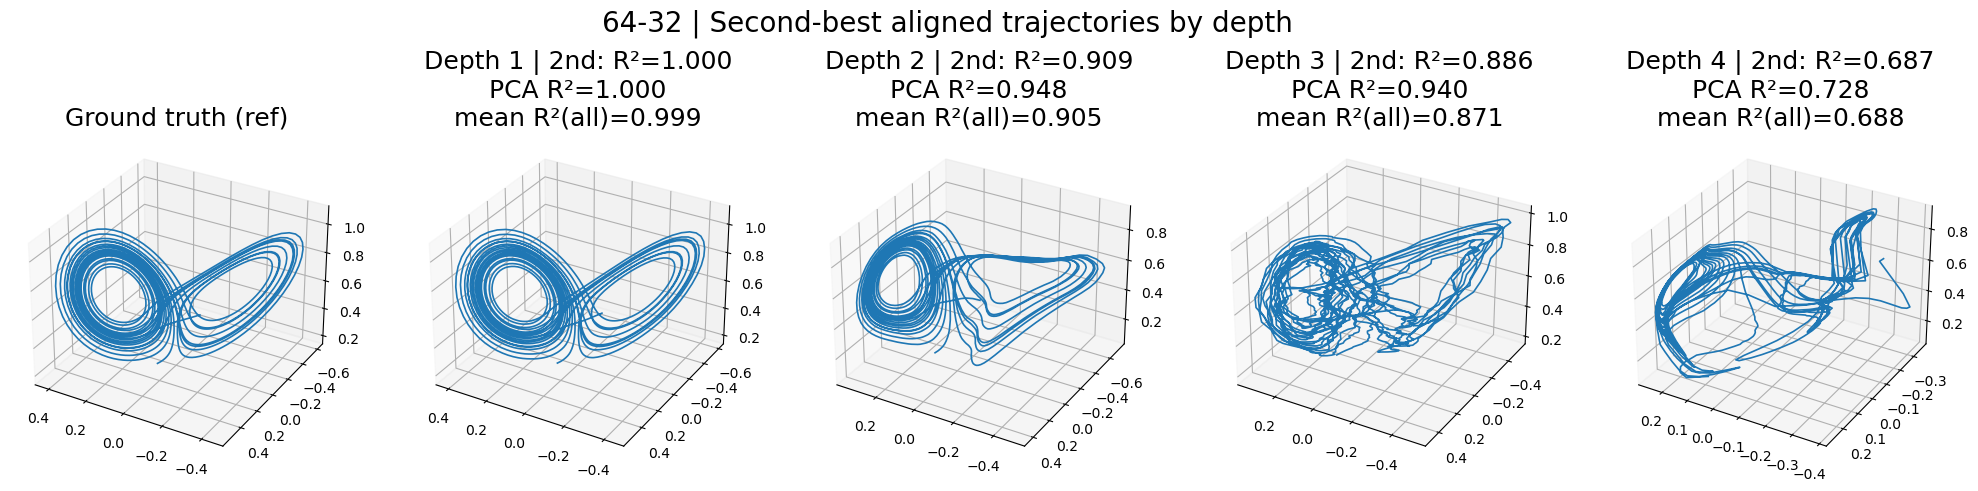

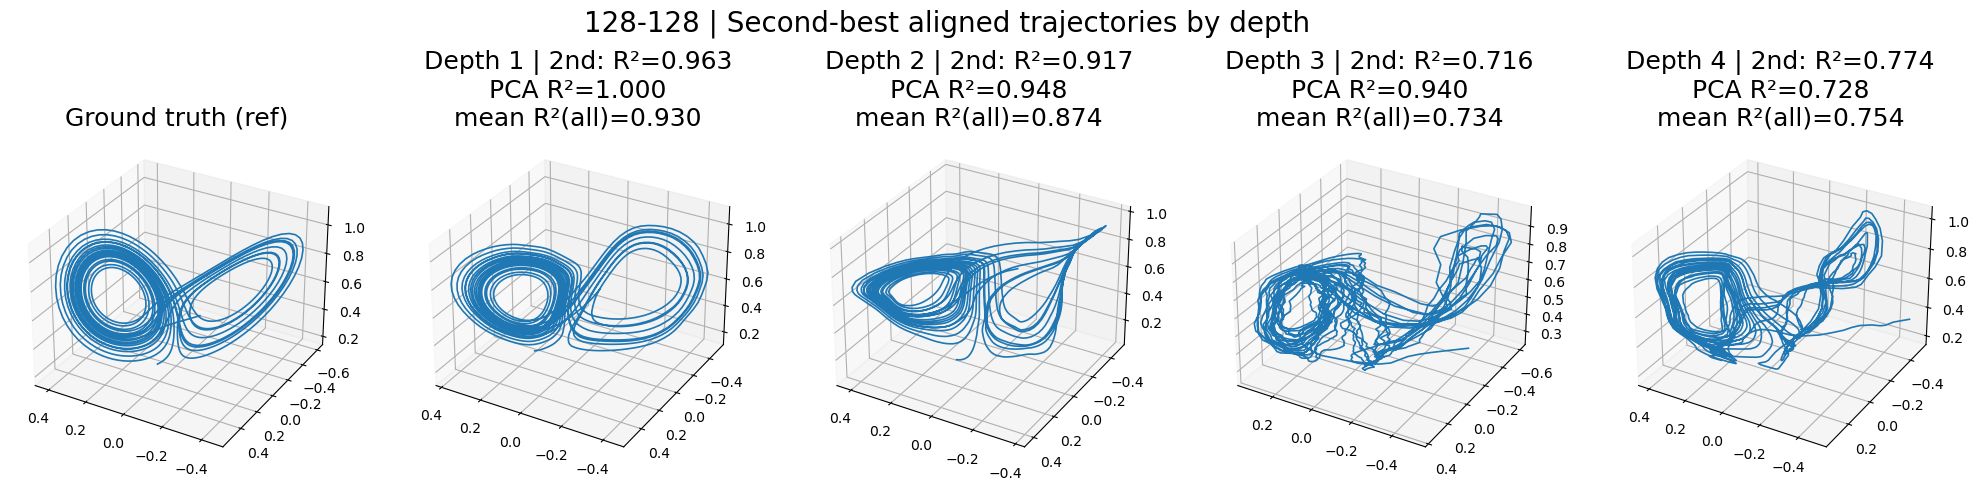

In [139]:
# load your two pickles (examples)
import pickle

with open("lorenz_latent_embeddings_4x2_orig.pkl", "rb") as f:
    emb64 = pickle.load(f)

with open("lorenz_latent_embeddings_4x2_128.pkl", "rb") as f:
    emb128 = pickle.load(f)

plot_two_architectures_64_128(emb64, emb128, azim=120,
                              save_path64="pics/architecture_summary_1x5_64-32_second_best.png",
                              save_path128="pics/architecture_summary_1x5_128-128_second_best.png")


In [134]:
import numpy as np
import matplotlib.pyplot as plt


def _r2s_by_depth(emb_store, depth_order=(1, 2, 3, 4), use="candidates"):
    """
    Returns:
      depths: np.array (D,)
      r2_list_per_depth: list length D, each element is a list[float] of R^2 values
    """
    depths = np.array([int(d) for d in depth_order], dtype=int)
    r2_list_per_depth = []

    for d in depths:
        D = emb_store["per_depth"][int(d)]
        if use == "candidates":
            r2s = [float(c["r2"]) for c in D["candidates"]]
        elif use == "best_only":
            r2s = [float(D["best"]["r2"])]
        else:
            raise ValueError("use must be 'candidates' or 'best_only'")
        r2_list_per_depth.append(r2s)

    return depths, r2_list_per_depth


def _mean_r2_by_depth(emb_store, depth_order=(1, 2, 3, 4), use="candidates"):
    depths, r2_list_per_depth = _r2s_by_depth(emb_store, depth_order=depth_order, use=use)

    mean_r2, std_r2, sem_r2, n_models = [], [], [], []
    for r2s in r2_list_per_depth:
        r2s = np.asarray(r2s, dtype=float)
        mean_r2.append(r2s.mean())
        std_r2.append(r2s.std(ddof=1) if len(r2s) > 1 else 0.0)
        sem_r2.append((r2s.std(ddof=1) / np.sqrt(len(r2s))) if len(r2s) > 1 else 0.0)
        n_models.append(len(r2s))

    return depths, np.array(mean_r2), np.array(std_r2), np.array(sem_r2), np.array(n_models)


def _pca_r2_by_depth(emb_store, depth_order=(1, 2, 3, 4)):
    """
    Returns:
      depths: np.array (D,)
      pca_r2: np.array (D,)
    """
    depths = np.array([int(d) for d in depth_order], dtype=int)
    pca_r2 = []
    for d in depths:
        D = emb_store["per_depth"][int(d)]
        pca_r2.append(float(D["pca"]["r2"]))
    return depths, np.array(pca_r2, dtype=float)


def plot_mean_r2_vs_mixing_layers_with_table_and_pca(
    emb64,
    emb128,
    *,
    depth_order=(1, 2, 3, 4),
    arch64_label="64-32",
    arch128_label="128-128",
    pca_label="PCA",
    use_for_table="candidates",
    show_errorbars=True,
    errorbar="sem",
    capsize=6,
    lw=3,
    marker="o",
    pca_ls="--",
    figsize=(15.5, 5.8),     # slightly wider
    table_fontsize=13,       # <-- bigger text
    table_scale=(1.15, 2.2), # <-- MUCH taller rows
    ylim=(0.0, 1.02),
    sort_cell_values=True,
    save_path=None,
):
    """
    1x2 layout:
      left: mean R^2 vs mixing_layers with error bars (two AEs) + PCA line
      right: table with rows=[64-32, 128-128, PCA], cols=depths
             - AE cells: list all R²s for that depth
             - PCA cells: single R²
    """
    # ---- curves: AE ----
    d64, m64, s64, sem64, n64 = _mean_r2_by_depth(emb64, depth_order=depth_order, use="candidates")
    d128, m128, s128, sem128, n128 = _mean_r2_by_depth(emb128, depth_order=depth_order, use="candidates")
    if not np.array_equal(d64, d128):
        raise ValueError("Depth grids differ between emb64 and emb128.")
    x = d64

    e64 = sem64 if errorbar == "sem" else s64
    e128 = sem128 if errorbar == "sem" else s128

    # ---- curve: PCA (should be identical across both emb stores if test data is identical)
    dp64, pca64 = _pca_r2_by_depth(emb64, depth_order=depth_order)
    dp128, pca128 = _pca_r2_by_depth(emb128, depth_order=depth_order)
    if not (np.array_equal(dp64, dp128) and np.allclose(pca64, pca128, atol=1e-12)):
        # Not fatal, but warn you by making it explicit.
        # We'll plot both if they differ.
        pca_same = False
    else:
        pca_same = True

    # ---- table data ----
    _, r2s64 = _r2s_by_depth(emb64, depth_order=depth_order, use=use_for_table)
    _, r2s128 = _r2s_by_depth(emb128, depth_order=depth_order, use=use_for_table)

    def _fmt_cell_many_with_mean(r2s):
        vals = [float(r) for r in r2s]
        if sort_cell_values:
            vals = sorted(vals, reverse=True)

        mu = float(np.mean(vals)) if len(vals) else float("nan")

        # Bold ONLY the mean line using MathText
        mean_line = rf"$\mathbf{{m={mu:.4f}}}$"
        other_lines = [f"{r:.4f}" for r in vals]

        return "\n".join(other_lines + [mean_line])

    def _fmt_cell_one(r):
        return f"{float(r):.4f}"

    col_labels = [str(int(d)) for d in depth_order]
    row_labels = [arch64_label, arch128_label, pca_label]

    # PCA row (use emb64’s PCA by default)
    pca_row = [_fmt_cell_one(r) for r in pca64]

    # ---- table data (now with mean in AE rows) ----
    cell_text = [
        [_fmt_cell_many_with_mean(r2s64[i]) for i in range(len(depth_order))],
        [_fmt_cell_many_with_mean(r2s128[i]) for i in range(len(depth_order))],
        pca_row,  # PCA stays single value
    ]

    # ---- figure ----
    fig, (ax, ax_tbl) = plt.subplots(
        1, 2, figsize=figsize, gridspec_kw={"width_ratios": [1.35, 1.0]}
    )

    # left: AE curves
    if show_errorbars:
        ax.errorbar(
            x, m64, yerr=e64, marker=marker, linewidth=lw, capsize=capsize,
            label=f"{arch64_label} (mean over {int(n64.max())} models)"
        )
        ax.errorbar(
            x, m128, yerr=e128, marker=marker, linewidth=lw, capsize=capsize,
            label=f"{arch128_label} (mean over {int(n128.max())} models)"
        )
    else:
        ax.plot(x, m64, marker=marker, linewidth=lw, label=arch64_label)
        ax.plot(x, m128, marker=marker, linewidth=lw, label=arch128_label)

    # PCA curve
    ax.plot(x, pca64, linestyle=pca_ls, linewidth=lw, marker=None, label=f"{pca_label}")
    if not pca_same:
        ax.plot(x, pca128, linestyle=":", linewidth=lw, marker=None, label=f"{pca_label} (from emb128)")

    ax.set_xlabel("# mixing_layers", fontsize=18)
    ax.set_ylabel("R² (affine-aligned)", fontsize=18)
    ax.set_xticks(list(x))
    ax.set_ylim(*ylim)
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False, fontsize=16)
    ax.set_title(
        "Mean latent reconstruction vs mixing depth",
        fontsize=22
    )

    # right: table
    ax_tbl.axis("off")
    tbl = ax_tbl.table(
        cellText=cell_text,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc="center",
        loc="center",
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(table_fontsize)
    tbl.scale(*table_scale)

    # ---- add top-left corner cell (row/column descriptor) ----
    corner_text = "mixing depth →\narchitecture ↓"

    # Matplotlib tables index:
    #   row = 0        -> header row
    #   col = -1       -> row-label column
    corner_cell = tbl.add_cell(
        0, -1,
        width=tbl[(0, 0)].get_width(),
        height=tbl[(0, 0)].get_height(),
        text=corner_text,
        loc="center"
    )

    corner_cell.set_text_props(
        fontsize=table_fontsize + 2,
        ha="center",
        va="center"
    )

    # ---- enlarge header + row label fonts explicitly ----
    #for (row, col), cell in tbl.get_celld().items():
    #    if row == 0 or col == -1:   # header row or row labels
    #        cell.set_text_props(fontsize=table_fontsize + 2, weight="bold")

    ax_tbl.set_title("Per-depth R² values", fontsize=22)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=600)
    plt.show()



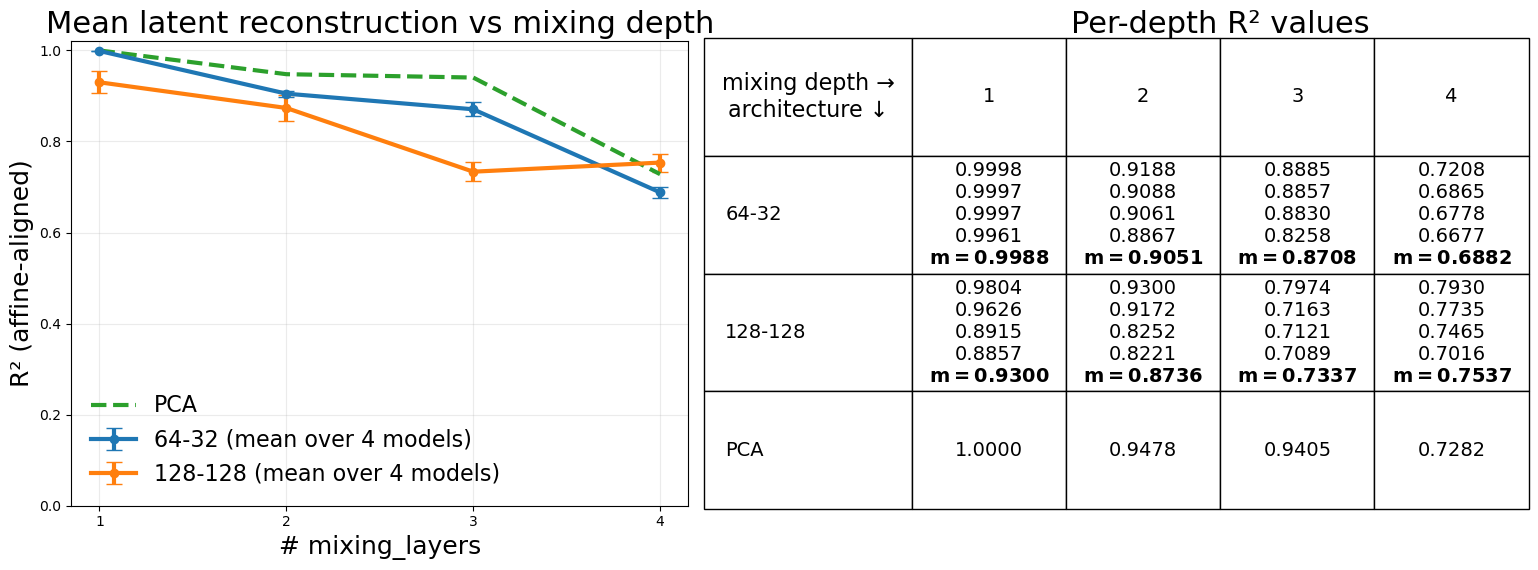

In [135]:
plot_mean_r2_vs_mixing_layers_with_table_and_pca(emb64, emb128, depth_order=(1,2,3,4),
                                                 figsize=(15.5, 5.8), table_fontsize=14,
                                                 table_scale=(1.35, 6.8),
                                                 save_path="pics/mean_r2_vs_mixing_layers_64_128.png")

## Loading and Plotting

In [128]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt


def plot_avg_losses_from_saved_models(
    pkl_paths,
    *,
    order=("total", "decoder", "sindy_x", "sindy_z", "sindy_regularization"),
    show_train=True,
    show_val=True,
    include_std_band=True,     # shaded ±1 std across models
    logy=False,
    title_prefix="",
    figsize=(6, 4),
    dpi=120,
    save_dir=None,             # e.g. "loss_plots/figs" or None
    save_prefix="avg_losses",
    show=True,
):
    """
    Load multiple saved per-model .pkl files (your payload format), compute mean loss curves
    across models, and create 5 separate plots:
      1) total
      2) decoder
      3) sindy_x
      4) sindy_z
      5) sindy_regularization

    Expected saved payload structure:
      payload["results_dict"]["training_losses"]   : (T, 5)
      payload["results_dict"]["validation_losses"] : (T, 5)
      payload["params"] includes loss weights:
        - loss_weight_decoder
        - loss_weight_sindy_x
        - loss_weight_sindy_z
        - loss_weight_sindy_regularization

    Notes:
    - "total" is whatever TensorFlow used as the training objective (already weighted).
    - component columns are whatever your `losses` dict returns (typically *unweighted* component tensors).
    - We display the weights in titles as requested, and print the total-loss formula.
    """

    if isinstance(pkl_paths, (str, os.PathLike)):
        pkl_paths = [str(pkl_paths)]
    pkl_paths = [str(p) for p in pkl_paths]
    if len(pkl_paths) == 0:
        raise ValueError("pkl_paths is empty.")

    # ----------------------------
    # Load all models
    # ----------------------------
    trains = []
    vals = []
    params_list = []
    meta_names = []

    for p in pkl_paths:
        with open(p, "rb") as f:
            payload = pickle.load(f)

        # accept either payload={"results_dict":..., "params":...} or raw results_dict
        if isinstance(payload, dict) and "results_dict" in payload:
            rd = payload["results_dict"]
            params = payload.get("params", {})
            name = os.path.basename(p)
        else:
            rd = payload
            params = {}
            name = os.path.basename(p)

        tr = np.asarray(rd.get("training_losses", None))
        va = np.asarray(rd.get("validation_losses", None))

        if tr is None or va is None:
            raise KeyError(
                f"File {p} missing training_losses/validation_losses in results_dict."
            )
        if tr.ndim != 2 or va.ndim != 2:
            raise ValueError(f"Loss arrays must be 2D. Got train {tr.shape}, val {va.shape} in {p}")
        if tr.shape[1] != len(order) or va.shape[1] != len(order):
            raise ValueError(
                f"Column mismatch in {p}: train {tr.shape}, val {va.shape}, len(order)={len(order)}.\n"
                f"Make sure `order` matches how you stored losses: {order}"
            )

        trains.append(tr)
        vals.append(va)
        params_list.append(params)
        meta_names.append(name)

    # ----------------------------
    # Align lengths (truncate to min length)
    # ----------------------------
    min_T = min(arr.shape[0] for arr in trains + vals)
    trains = [arr[:min_T] for arr in trains]
    vals   = [arr[:min_T] for arr in vals]

    trains = np.stack(trains, axis=0)   # (M, T, 5)
    vals   = np.stack(vals, axis=0)     # (M, T, 5)

    M, T, K = trains.shape
    x = np.arange(T)

    # ----------------------------
    # Decide which weights to show
    # (assume same weights across models; if not, we warn and use the first)
    # ----------------------------
    def _get_w(params, key, default=0.0):
        try:
            return float(params.get(key, default))
        except Exception:
            return float(default)

    w_dec = _get_w(params_list[0], "loss_weight_decoder", 0.0)
    w_x   = _get_w(params_list[0], "loss_weight_sindy_x", 0.0)
    w_z   = _get_w(params_list[0], "loss_weight_sindy_z", 0.0)
    w_reg = _get_w(params_list[0], "loss_weight_sindy_regularization", 0.0)

    # check consistency
    for i, pr in enumerate(params_list[1:], start=1):
        wd = _get_w(pr, "loss_weight_decoder", w_dec)
        wx = _get_w(pr, "loss_weight_sindy_x", w_x)
        wz = _get_w(pr, "loss_weight_sindy_z", w_z)
        wr = _get_w(pr, "loss_weight_sindy_regularization", w_reg)
        if (wd, wx, wz, wr) != (w_dec, w_x, w_z, w_reg):
            print(
                "[WARN] Loss weights differ across models. "
                f"Using weights from first model only: "
                f"w_dec={w_dec}, w_x={w_x}, w_z={w_z}, w_reg={w_reg}."
            )
            break

    # ----------------------------
    # Compute mean/std
    # ----------------------------
    def _mean_std(arr):  # arr: (M,T)
        mu = arr.mean(axis=0)
        sd = arr.std(axis=0, ddof=0)
        return mu, sd

    # mapping from name->col index
    idx = {name: i for i, name in enumerate(order)}

    # helper to plot one component
    def _plot_component(comp_key, ylabel, title, weight=None):
        plt.figure(figsize=figsize, dpi=dpi)

        if show_train:
            mu, sd = _mean_std(trains[:, :, idx[comp_key]])
            plt.plot(x, mu, label="train (mean)")
            if include_std_band and M > 1:
                plt.fill_between(x, mu - sd, mu + sd, alpha=0.2)

        if show_val:
            mu, sd = _mean_std(vals[:, :, idx[comp_key]])
            plt.plot(x, mu, label="val (mean)")
            if include_std_band and M > 1:
                plt.fill_between(x, mu - sd, mu + sd, alpha=0.2)

        if logy:
            plt.yscale("log")

        plt.xlabel("epoch")
        plt.ylabel(ylabel)

        if weight is None:
            plt.title(f"{title_prefix}{title}  |  {M} models".strip())
        else:
            plt.title(f"{title_prefix}{title}  |  weight={weight:g}  |  {M} models".strip())

        plt.legend()
        plt.tight_layout()

        if save_dir is not None:
            os.makedirs(save_dir, exist_ok=True)
            out_path = os.path.join(save_dir, f"{save_prefix}_{comp_key}.png")
            plt.savefig(out_path, bbox_inches="tight")
            print("Saved:", out_path)

        if show:
            plt.show()
        else:
            plt.close()

    # ----------------------------
    # Plot TOTAL with formula in title
    # ----------------------------
    total_formula = (
        r"$\mathcal{L} = "
        f"{w_dec:g}\,\mathcal{{L}}_{{dec}} + "
        f"{w_x:g}\,\mathcal{{L}}_{{sindy\_x}} + "
        f"{w_z:g}\,\mathcal{{L}}_{{sindy\_z}} + "
        f"{w_reg:g}\,\mathcal{{L}}_{{reg}}$"
    )

    _plot_component(
        "total",
        ylabel="total loss",
        title=f"Total loss. {total_formula}",
        weight=None,  # already included in formula
    )

    # ----------------------------
    # Plot components (each separate figure)
    # ----------------------------
    _plot_component("decoder", "decoder loss", "Decoder loss", weight=w_dec)
    _plot_component("sindy_x", "SINDy x loss", "SINDy loss in x", weight=w_x)
    _plot_component("sindy_z", "SINDy z loss", "SINDy loss in z", weight=w_z)
    _plot_component("sindy_regularization", "L1 regularization", "Regularization loss", weight=w_reg)

    return {
        "n_models": M,
        "n_epochs_truncated": T,
        "weights_used": {
            "loss_weight_decoder": w_dec,
            "loss_weight_sindy_x": w_x,
            "loss_weight_sindy_z": w_z,
            "loss_weight_sindy_regularization": w_reg,
        },
        "order_used": order,
        "files": meta_names,
    }


Saved: loss_plots/figs\orig_64x32_avg_total.png


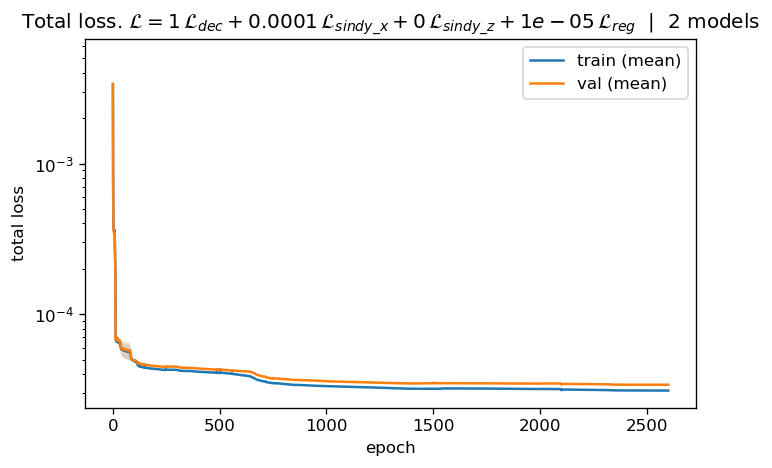

Saved: loss_plots/figs\orig_64x32_avg_decoder.png


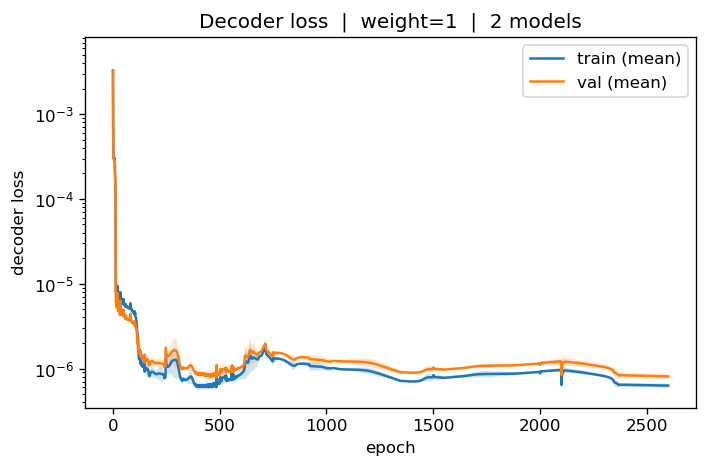

Saved: loss_plots/figs\orig_64x32_avg_sindy_x.png


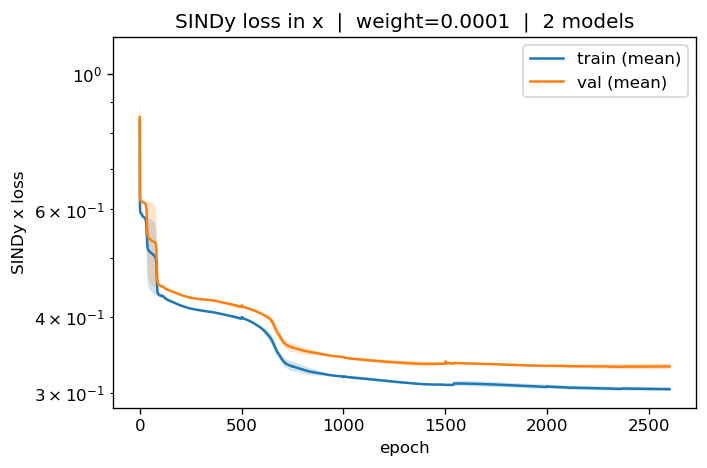

Saved: loss_plots/figs\orig_64x32_avg_sindy_z.png


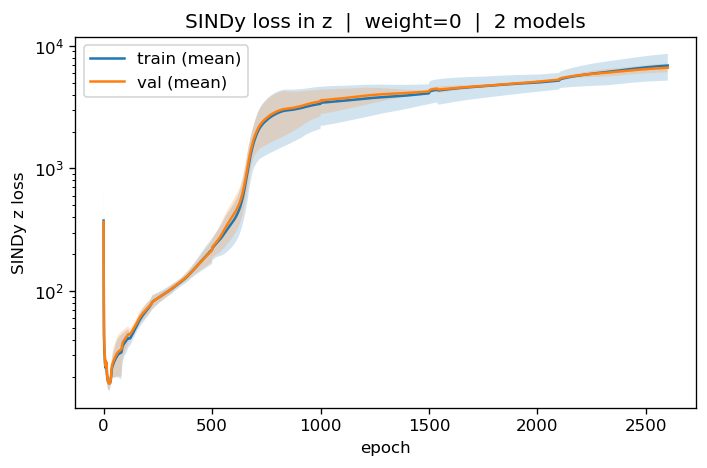

Saved: loss_plots/figs\orig_64x32_avg_sindy_regularization.png


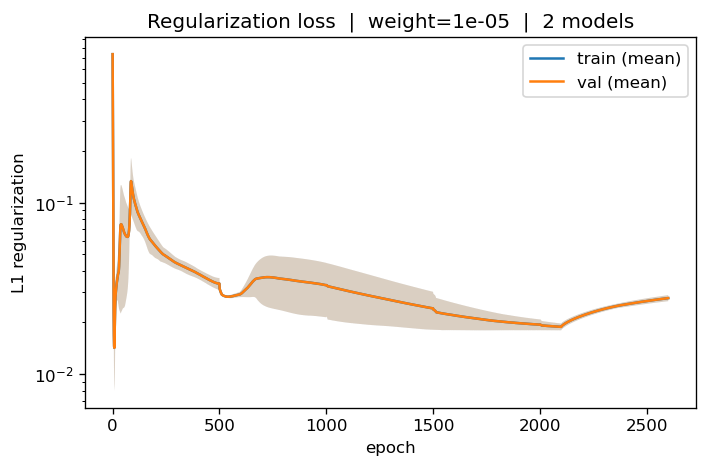

{'n_models': 2, 'n_epochs_truncated': 2602, 'weights_used': {'loss_weight_decoder': 1.0, 'loss_weight_sindy_x': 0.0001, 'loss_weight_sindy_z': 0.0, 'loss_weight_sindy_regularization': 1e-05}, 'order_used': ('total', 'decoder', 'sindy_x', 'sindy_z', 'sindy_regularization'), 'files': ['results_orig_errors_depth-4_trainseed-147.pkl', 'results_orig_errors_depth-4_trainseed-148.pkl']}


In [130]:
import glob

paths = sorted(glob.glob("loss_plots/results_orig_errors_depth-4_trainseed-*.pkl"))
summary = plot_avg_losses_from_saved_models(
    paths,
    logy=True,
    save_dir="loss_plots/figs",
    save_prefix="orig_64x32_avg",
)
print(summary)


In [124]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt


def _load_loss_stack(pkl_paths, order):
    """Loads a list of per-model pkls -> stacked train/val arrays + params list."""
    if isinstance(pkl_paths, (str, os.PathLike)):
        pkl_paths = [str(pkl_paths)]
    pkl_paths = [str(p) for p in pkl_paths]
    if len(pkl_paths) == 0:
        raise ValueError("pkl_paths is empty.")

    trains, vals, params_list, names = [], [], [], []

    for p in pkl_paths:
        with open(p, "rb") as f:
            payload = pickle.load(f)

        if isinstance(payload, dict) and "results_dict" in payload:
            rd = payload["results_dict"]
            params = payload.get("params", {})
        else:
            rd = payload
            params = {}

        tr = np.asarray(rd.get("training_losses", None))
        va = np.asarray(rd.get("validation_losses", None))

        if tr is None or va is None:
            raise KeyError(f"{p} missing training_losses/validation_losses.")
        if tr.ndim != 2 or va.ndim != 2:
            raise ValueError(f"{p}: loss arrays must be 2D. Got train {tr.shape}, val {va.shape}.")
        if tr.shape[1] != len(order) or va.shape[1] != len(order):
            raise ValueError(
                f"{p}: column mismatch. train {tr.shape}, val {va.shape}, len(order)={len(order)}.\n"
                f"order={order}"
            )

        trains.append(tr)
        vals.append(va)
        params_list.append(params)
        names.append(os.path.basename(p))

    # truncate to common length inside this architecture
    min_T = min(a.shape[0] for a in trains + vals)
    trains = [a[:min_T] for a in trains]
    vals   = [a[:min_T] for a in vals]

    trains = np.stack(trains, axis=0)  # (M,T,K)
    vals   = np.stack(vals, axis=0)

    return trains, vals, params_list, names


def _get_weights(params, defaults=(0.0, 0.0, 0.0, 0.0)):
    def _g(k, d):
        try:
            return float(params.get(k, d))
        except Exception:
            return float(d)

    w_dec = _g("loss_weight_decoder", defaults[0])
    w_x   = _g("loss_weight_sindy_x", defaults[1])
    w_z   = _g("loss_weight_sindy_z", defaults[2])
    w_reg = _g("loss_weight_sindy_regularization", defaults[3])
    return w_dec, w_x, w_z, w_reg


def plot_avg_losses_two_arch_1x2(
    pkl_paths_64,
    pkl_paths_128,
    *,
    order=("total", "decoder", "sindy_x", "sindy_z", "sindy_regularization"),
    arch64_label="64-32",
    arch128_label="128-128",
    show_train=True,
    show_val=True,
    include_std_band=True,
    logy=False,
    title_prefix="",
    figsize_per_fig=(15.0, 5.2),   # one figure per component, with 1x2 subplots
    dpi=120,
    save_dir=None,
    save_prefix="avg_losses",
    show=True,
    sharey=True,                  # share y-axis between the two subplots
):
    """
    For each loss component in `order`, produce ONE figure with a 1x2 layout:
      left  = 64-32 mean±std (train/val)
      right = 128-128 mean±std (train/val)

    Returns a summary dict.
    """
    # ----------------------------
    # Load both architectures
    # ----------------------------
    tr64, va64, params64_list, names64 = _load_loss_stack(pkl_paths_64, order)
    tr128, va128, params128_list, names128 = _load_loss_stack(pkl_paths_128, order)

    # ----------------------------
    # Align across architectures (truncate both to the same epoch length)
    # ----------------------------
    T = min(tr64.shape[1], tr128.shape[1], va64.shape[1], va128.shape[1])
    tr64, va64 = tr64[:, :T], va64[:, :T]
    tr128, va128 = tr128[:, :T], va128[:, :T]
    x = np.arange(T)

    M64, _, K = tr64.shape
    M128, _, _ = tr128.shape

    idx = {name: i for i, name in enumerate(order)}

    # weights (shown in titles). We assume consistent inside each arch.
    w64 = _get_weights(params64_list[0] if params64_list else {})
    w128 = _get_weights(params128_list[0] if params128_list else {})

    def _mean_std(arr_2d):  # (M,T)
        mu = arr_2d.mean(axis=0)
        sd = arr_2d.std(axis=0, ddof=0)
        return mu, sd

    def _plot_on_ax(ax, trains, vals, comp_key, arch_label, weights):
        col = idx[comp_key]

        if show_train:
            mu, sd = _mean_std(trains[:, :, col])
            ax.plot(x, mu, label="train (mean)")
            if include_std_band and trains.shape[0] > 1:
                ax.fill_between(x, mu - sd, mu + sd, alpha=0.2)

        if show_val:
            mu, sd = _mean_std(vals[:, :, col])
            ax.plot(x, mu, label="val (mean)")
            if include_std_band and vals.shape[0] > 1:
                ax.fill_between(x, mu - sd, mu + sd, alpha=0.2)

        if logy:
            ax.set_yscale("log")

        ax.set_xlabel("epoch")
        ax.set_title(arch_label)

        ax.grid(True, alpha=0.25)
        ax.legend(frameon=False)

    def _title_for_component(comp_key, weights):
        w_dec, w_x, w_z, w_reg = weights

        if comp_key == "total":
            formula = (
                r"$\mathcal{L} = "
                f"{w_dec:g}\,\mathcal{{L}}_{{dec}} + "
                f"{w_x:g}\,\mathcal{{L}}_{{sindy\\_x}} + "
                f"{w_z:g}\,\mathcal{{L}}_{{sindy\\_z}} + "
                f"{w_reg:g}\,\mathcal{{L}}_{{reg}}$"
            )
            return f"{title_prefix}Total loss  |  {formula}".strip()

        weight_map = {
            "decoder": ("Decoder loss", w_dec),
            "sindy_x": ("SINDy loss in x", w_x),
            "sindy_z": ("SINDy loss in z", w_z),
            "sindy_regularization": ("Regularization loss", w_reg),
        }
        label, w = weight_map[comp_key]
        return f"{title_prefix}{label}  |  weight={w:g}".strip()

    ylabels = {
        "total": "total loss",
        "decoder": "decoder loss",
        "sindy_x": "SINDy x loss",
        "sindy_z": "SINDy z loss",
        "sindy_regularization": "L1 regularization",
    }

    # ----------------------------
    # One figure per component, each figure is 1x2
    # ----------------------------
    for comp_key in order:
        fig, axes = plt.subplots(
            1, 2, figsize=figsize_per_fig, dpi=dpi, sharey=sharey
        )

        _plot_on_ax(axes[0], tr64, va64, comp_key, arch64_label, w64)
        _plot_on_ax(axes[1], tr128, va128, comp_key, arch128_label, w128)

        axes[0].set_ylabel(ylabels[comp_key])

        # Put the informative title on the whole figure (use weights from *each* arch if you want)
        # Here: if total, show both formulas; else show both weights.
        if comp_key == "total":
            t64 = _title_for_component("total", w64)
            t128 = _title_for_component("total", w128)
            fig.suptitle(f"{t64}\n{t128}", fontsize=12)
        else:
            t64 = _title_for_component(comp_key, w64)
            t128 = _title_for_component(comp_key, w128)
            fig.suptitle(f"{t64}\n{t128}", fontsize=12)

        plt.tight_layout(rect=[0, 0, 1, 0.90])

        if save_dir is not None:
            os.makedirs(save_dir, exist_ok=True)
            out_path = os.path.join(save_dir, f"{save_prefix}_{comp_key}_1x2.png")
            plt.savefig(out_path, bbox_inches="tight")
            print("Saved:", out_path)

        if show:
            plt.show()
        else:
            plt.close(fig)

    return {
        "n_models": {arch64_label: int(M64), arch128_label: int(M128)},
        "n_epochs_truncated": int(T),
        "weights_used": {
            arch64_label: {
                "loss_weight_decoder": w64[0],
                "loss_weight_sindy_x": w64[1],
                "loss_weight_sindy_z": w64[2],
                "loss_weight_sindy_regularization": w64[3],
            },
            arch128_label: {
                "loss_weight_decoder": w128[0],
                "loss_weight_sindy_x": w128[1],
                "loss_weight_sindy_z": w128[2],
                "loss_weight_sindy_regularization": w128[3],
            },
        },
        "order_used": order,
        "files": {arch64_label: names64, arch128_label: names128},
    }


Saved: loss_plots/figs\depth4_total_1x2.png


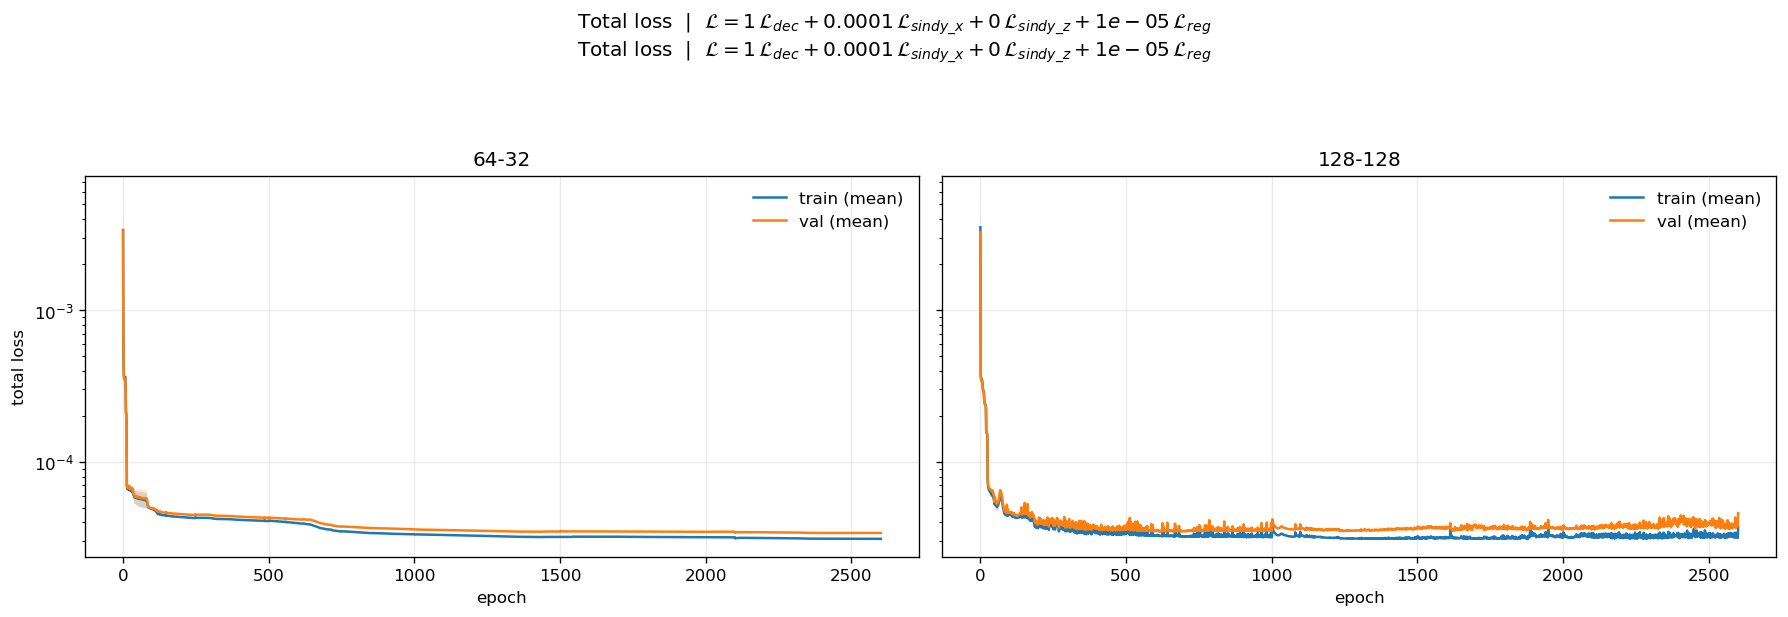

Saved: loss_plots/figs\depth4_decoder_1x2.png


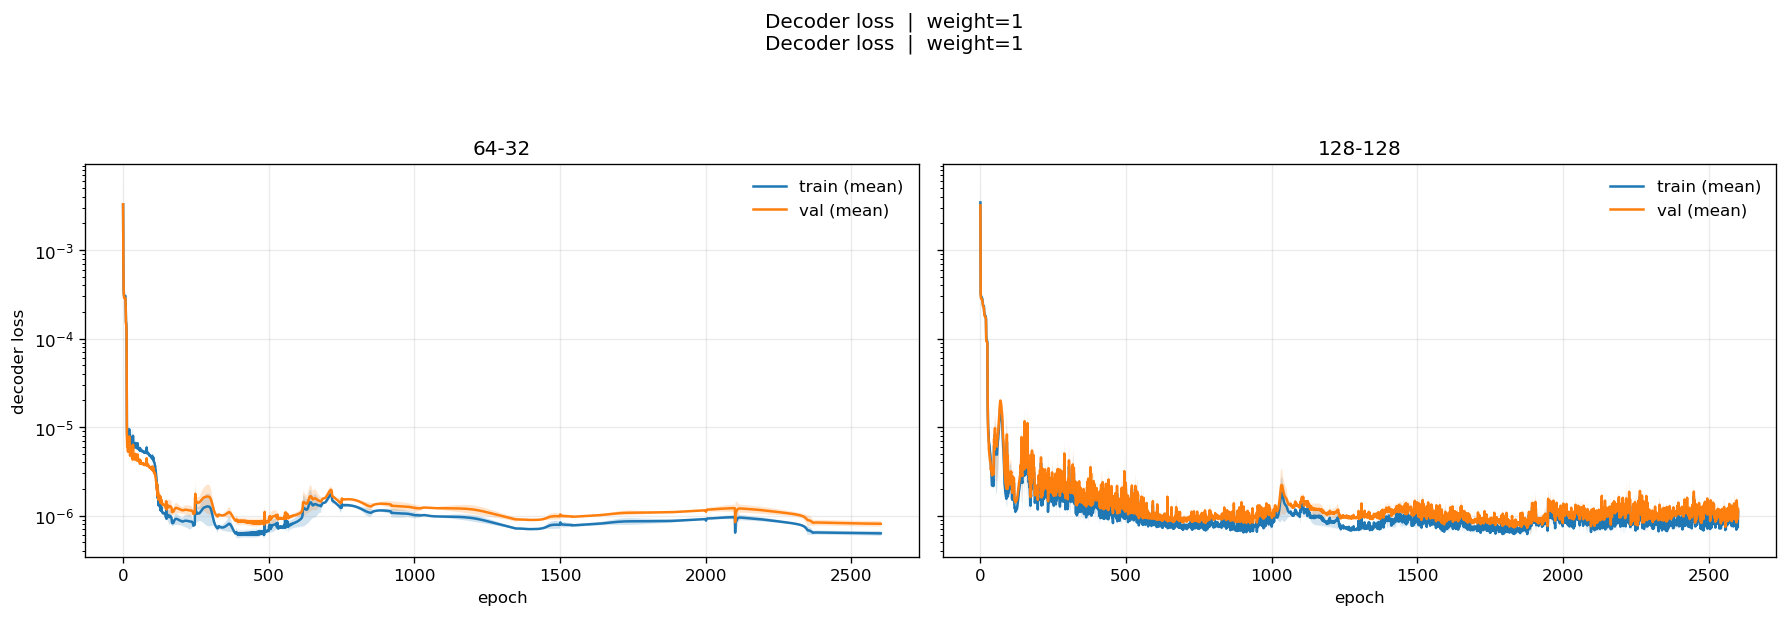

Saved: loss_plots/figs\depth4_sindy_x_1x2.png


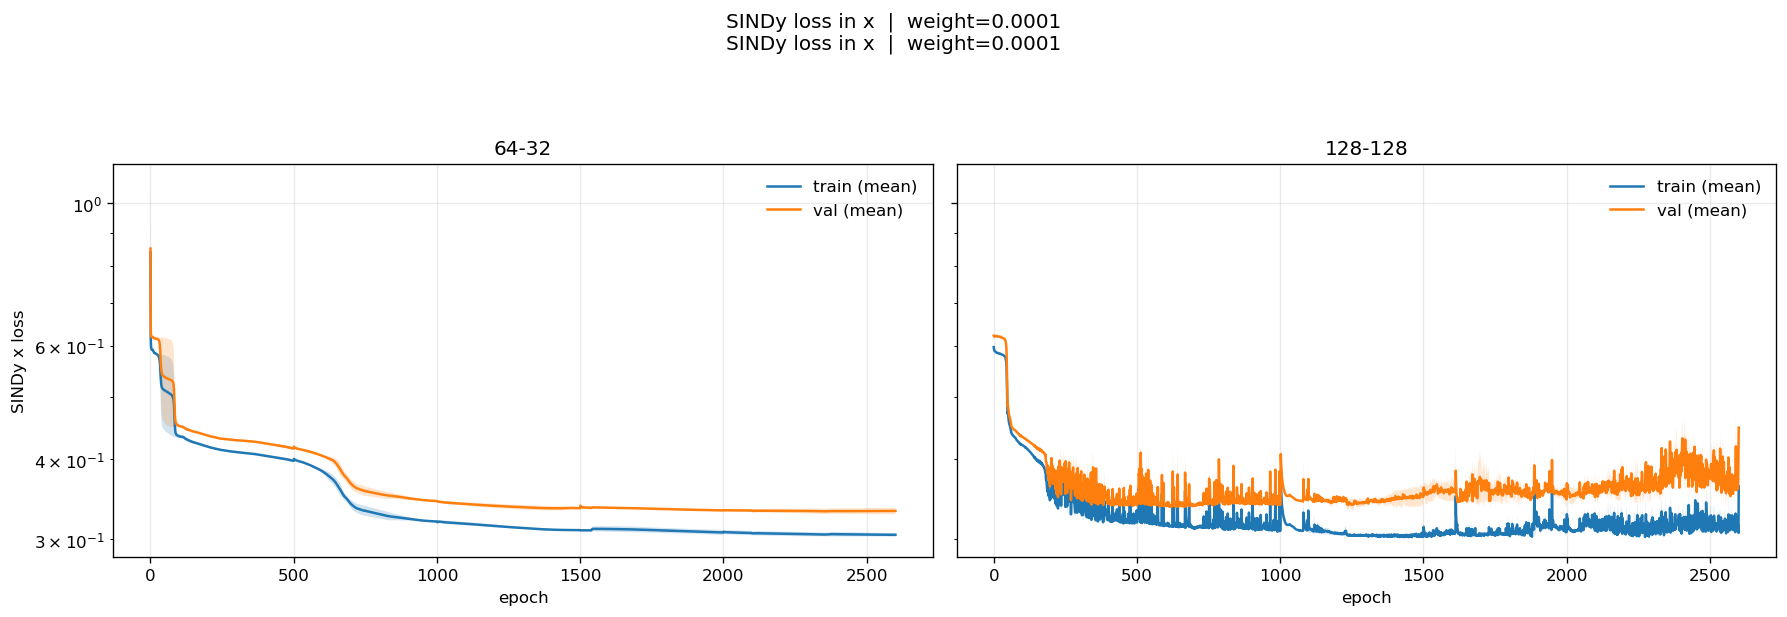

Saved: loss_plots/figs\depth4_sindy_z_1x2.png


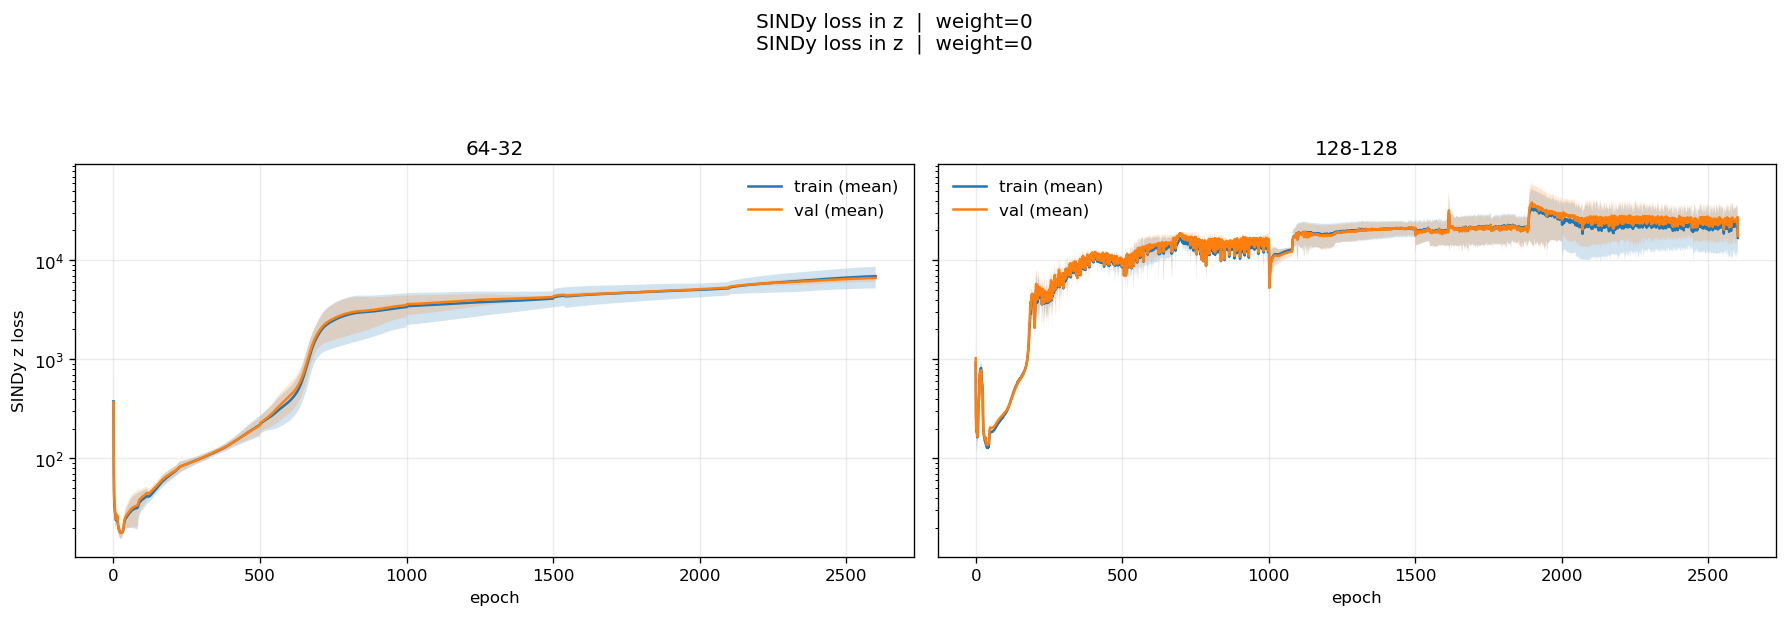

Saved: loss_plots/figs\depth4_sindy_regularization_1x2.png


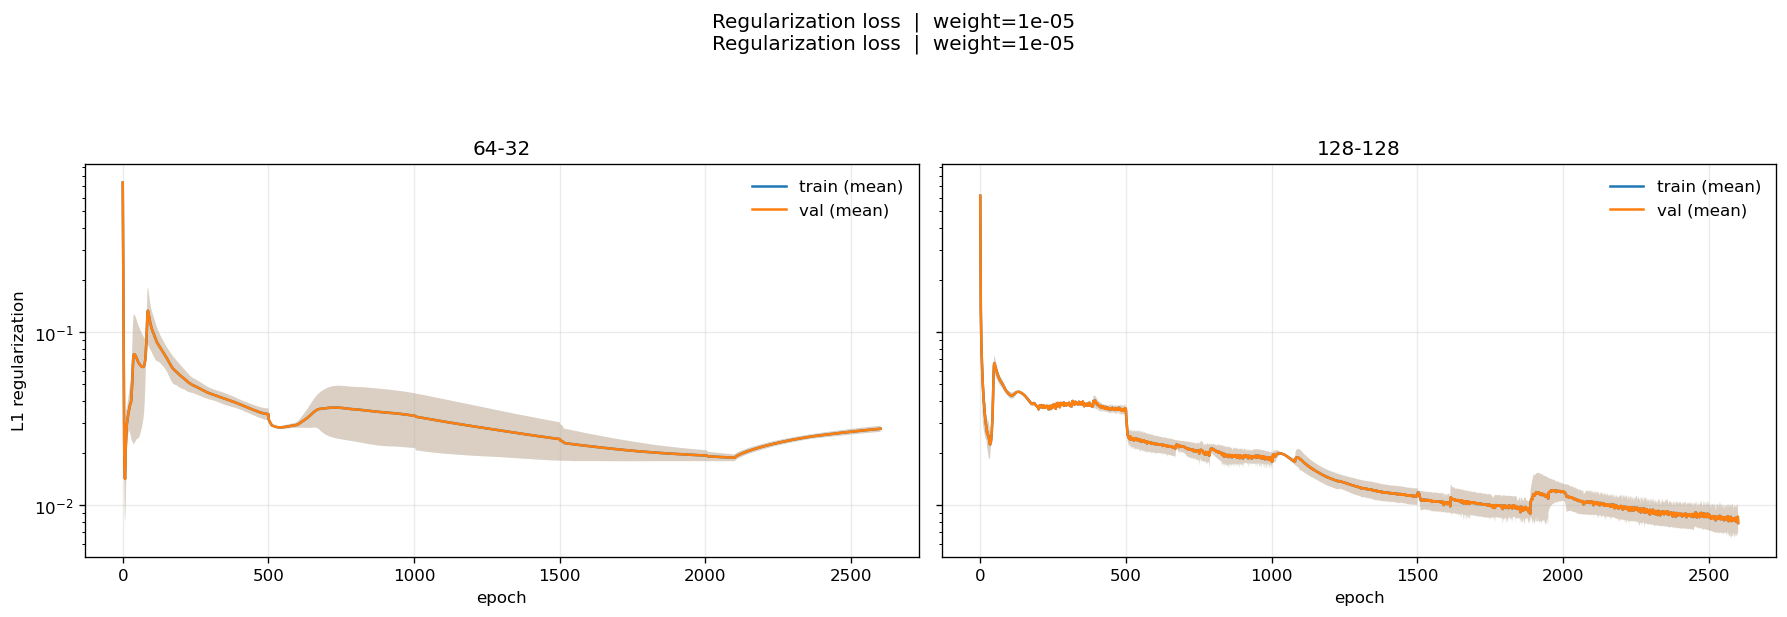

In [125]:
paths64  = sorted(glob.glob("loss_plots/results_orig_errors_depth-4_trainseed-*.pkl"))
paths128 = sorted(glob.glob("loss_plots/results_128_errors_depth-4_trainseed-*.pkl"))

summary = plot_avg_losses_two_arch_1x2(
    paths64, paths128,
    arch64_label="64-32",
    arch128_label="128-128",
    logy=True,
    save_dir="loss_plots/figs",
    save_prefix="depth4",
)
